# Recipe Rating Prediction – Exploratory Data Analysis (EDA)

Objective:
Understand user behavior, engagement patterns, and review characteristics to identify factors influencing recipe ratings.

Dataset:
Recipe Ratings Dataset (train.csv)

Problem Type:
Multi-class Classification (Predict rating from 1 to 5)

# Feature Description
- RecipeNumber: Placement of the recipe on the top 100 recipes list
- RecipeCode: Unique ID of the recipe used by the site
- RecipeName: Name of the recipe the comment was posted on
- CommentID: Unique ID of the comment
- UserID: Unique ID of the user who left the comment
- UserName: Name of the user
- UserReputation: Internal score of the site, roughly quantifying the past behavior of the user
- CreationTimestamp: Time at which the comment was posted as a Unix timestamp
- ReplyCount: Number of replies to the comment
- ThumbsUpCount: Number of up-votes the comment has received
- ThumbsDownCount: Number of down-votes the comment has received
- Rating: The score on a 1 to 5 scale that the user gave to the recipe. A score of 0 means that no score was given (Target Variable)
- BestScore: Score of the comment, likely used by the site to help determine the order comments appear in
- Recipe_Review: Text content of the comment


In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [2]:
# Set the visual style
sns.set_theme(style="whitegrid")


# Import & Load Data

In [3]:
test = pd.read_csv(r"D:\Bridgeon\Projects\recipe_rating_ML_project\data\test.csv")
train = pd.read_csv(r"D:\Bridgeon\Projects\recipe_rating_ML_project\data\train.csv")

orginal_train_data = train.copy()


### Look for shape to understand the dataset size

In [4]:
print(train.shape)# which has 15 column include target Rating
print(test.shape)# which has 14 column 

(13636, 15)
(4546, 14)


# Dataset Overview

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13636 entries, 0 to 13635
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 13636 non-null  int64 
 1   RecipeNumber       13636 non-null  int64 
 2   RecipeCode         13636 non-null  int64 
 3   RecipeName         13636 non-null  object
 4   CommentID          13636 non-null  object
 5   UserID             13636 non-null  object
 6   UserName           13636 non-null  object
 7   UserReputation     13636 non-null  int64 
 8   CreationTimestamp  13636 non-null  int64 
 9   ReplyCount         13636 non-null  int64 
 10  ThumbsUpCount      13636 non-null  int64 
 11  ThumbsDownCount    13636 non-null  int64 
 12  Rating             13636 non-null  int64 
 13  BestScore          13636 non-null  int64 
 14  Recipe_Review      13634 non-null  object
dtypes: int64(10), object(5)
memory usage: 1.6+ MB


In [6]:
train.head(5)

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
0,70,71,12259,Banana Bars with Cream Cheese Frosting,sp_aUSaElGf_12259_c_149978,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,20,1622717078,0,0,0,5,100,great recipe! I have made them just as written...
1,72,88,8202,Simple Taco Soup,sp_aUSaElGf_8202_c_310332,u_1oKZeRIXYzGNhGW8OMR3O4lX1ih,MichelleMalone,1,1622717852,0,0,1,5,100,This is an easy and quick recipe that is great...
2,458,3,2832,Cheeseburger Soup,sp_aUSaElGf_2832_c_206522,u_1oKYHUtdaD48KJCDYq5wfpAUxWz,jeannem32,1,1622717357,0,0,0,3,100,I think I was looking for something extra spec...
3,7,50,100276,Grilled Huli Huli Chicken,sp_aUSaElGf_100276_c_434088,u_1oKZCQcKQZdQhDVBS7oISc216VA,ds422,1,1622648899,0,0,0,5,100,This is our favorite grilled chicken recipe. ...
4,60,12,19731,Cauliflower Soup,sp_aUSaElGf_19731_c_387011,u_1oKd4sudZQPgu6YALiC7bW7mKMs,SusanHoward,1,1622718260,0,0,0,4,100,Great basic recipe. I added 2 teaspoons Tuscan...


There are specific columns that are not very usfull, like 
- ID - No predictive meaning
- RecipeCode - No mathematical meaning and may reduntent 
- CommentID - No predictive meaning
- UserID -
- UserName - No numeric meaning
  

In [36]:
print(train['RecipeNumber'].value_counts())
print(train['RecipeCode'].value_counts())
print('*'*30)
print(train.groupby('RecipeNumber')['RecipeCode'].nunique()) # it will help understand in each group how much different elements present if all are 1 then reduntent.

RecipeNumber
3     553
1     483
2     372
9     313
13    307
     ... 
54     68
97     65
91     64
72     64
61     19
Name: count, Length: 100, dtype: int64
RecipeCode
2832     553
14299    483
3309     372
42083    313
32480    307
        ... 
35766     68
34347     65
3683      64
1821      64
17022     19
Name: count, Length: 100, dtype: int64
******************************
RecipeNumber
1      1
2      1
3      1
4      1
5      1
      ..
96     1
97     1
98     1
99     1
100    1
Name: RecipeCode, Length: 100, dtype: int64


- **Perfect 1-to-1 mapping**
- **Fully redundant**
- **One must be dropped**

# Numerical Features — Summary Statistics and Distributions

In [8]:
train.describe()


,ID,RecipeNumber,RecipeCode,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore
count,13636.000000,13636.000000,13636.000000,13636.000000,1.363600e+04,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000
mean,121.085289,38.624377,21785.990833,2.160311,1.623713e+09,0.014520,1.098269,0.543708,4.288721,153.127897
std,116.995633,29.672351,23883.189918,10.086424,5.444020e+06,0.137323,4.166487,3.265660,1.544839,140.986908
min,0.000000,1.000000,386.000000,0.000000,1.613035e+09,0.000000,0.000000,0.000000,0.000000,0.000000
25%,45.000000,12.000000,6504.000000,1.000000,1.622717e+09,0.000000,0.000000,0.000000,5.000000,100.000000
50%,91.000000,33.000000,14600.000000,1.000000,1.622718e+09,0.000000,0.000000,0.000000,5.000000,100.000000
75%,148.000000,63.000000,33121.000000,1.000000,1.622718e+09,0.000000,0.000000,0.000000,5.000000,100.000000
max,724.000000,100.000000,191775.000000,510.000000,1.665756e+09,3.000000,80.000000,126.000000,5.000000,946.000000


**info** give us overall details

## Distributions of Numerical Features

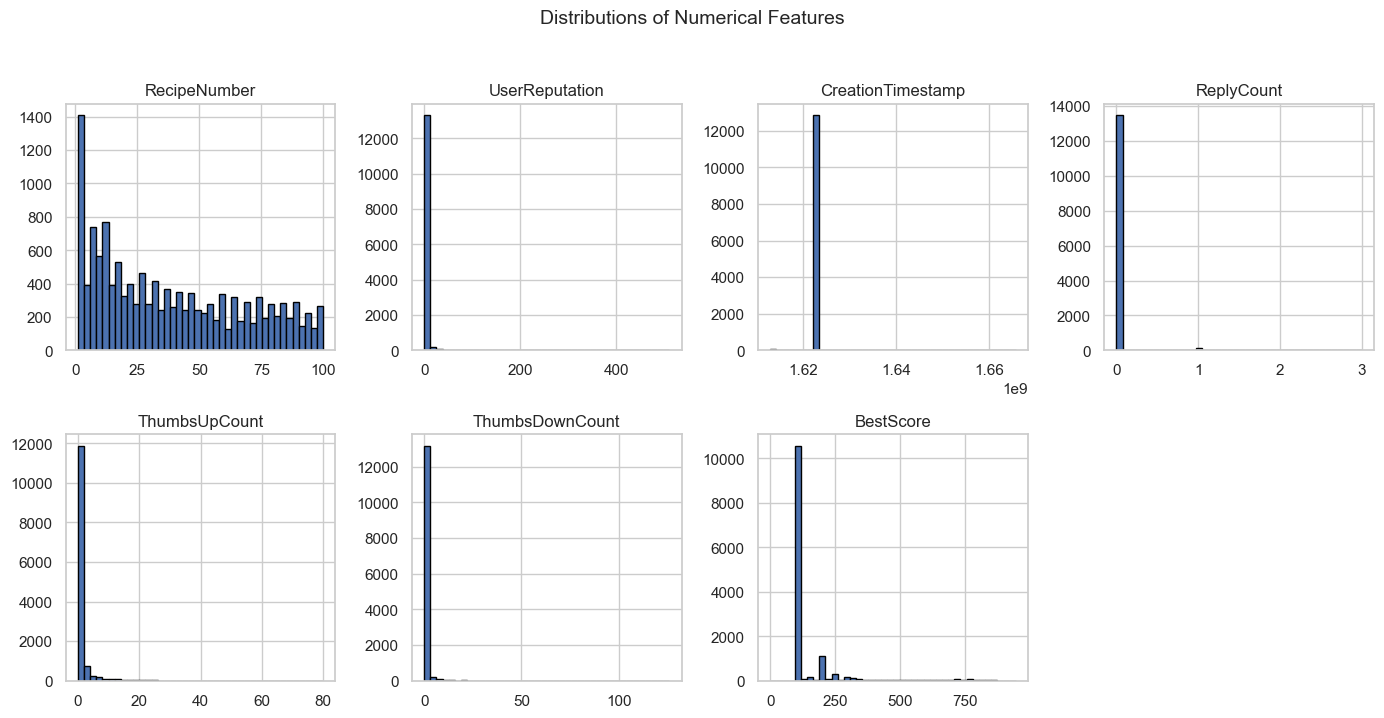

In [9]:
num_cols = ['RecipeNumber', 'UserReputation','CreationTimestamp', 'ReplyCount', 'ThumbsUpCount', 'ThumbsDownCount', 'BestScore']
train[num_cols].hist(bins=40, figsize=(14, 10), edgecolor="black", layout=(3, 4))
plt.suptitle("Distributions of Numerical Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

- **RecipeNumber** : No scaling problem,No extreme skew
- **UserReputation** : Highly skewed, need log transformation in pipeline
- **CreationTimestamp** : Raw timestamp not useful, Extract hour/day/month, Then drop this
- **ThumbsUpCount and ThumbsDownCount** : Log transform needed

# Target Variable (Rating) Analysis

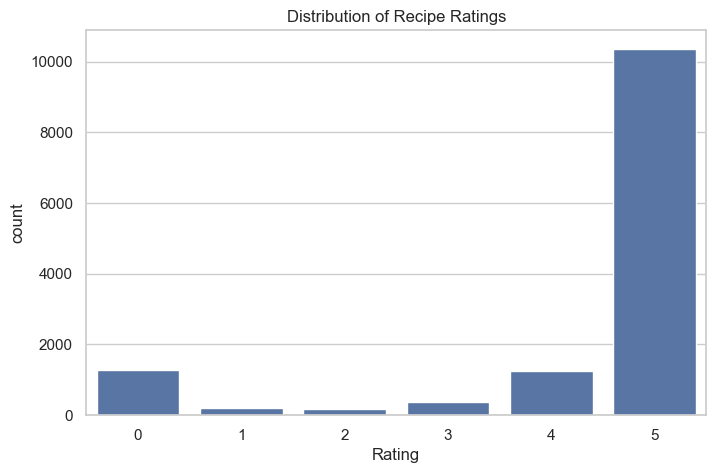

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=train, x='Rating' )
plt.title("Distribution of Recipe Ratings")
plt.show()

This indicates a **class imbalance problem**, which may bias the model toward predicting rating 5 more frequently.
If `Rating = 0` means no rating, these rows should be removed before training.
- Rating = 5 dominates heavily
- Accuracy alone is misleading
- Rating = 0 Exists (A score on a 1 to 5 scale. A score of 0 means no score was given.)

# Missing Values Analysis

In [11]:
train.isna().sum()

ID                   0
RecipeNumber         0
RecipeCode           0
RecipeName           0
CommentID            0
UserID               0
UserName             0
UserReputation       0
CreationTimestamp    0
ReplyCount           0
ThumbsUpCount        0
ThumbsDownCount      0
Rating               0
BestScore            0
Recipe_Review        2
dtype: int64

there is 2 missing values in **Recipe_Review** but it not important,
- decide to replace with **"No Review"**

# Reputation vs Rating

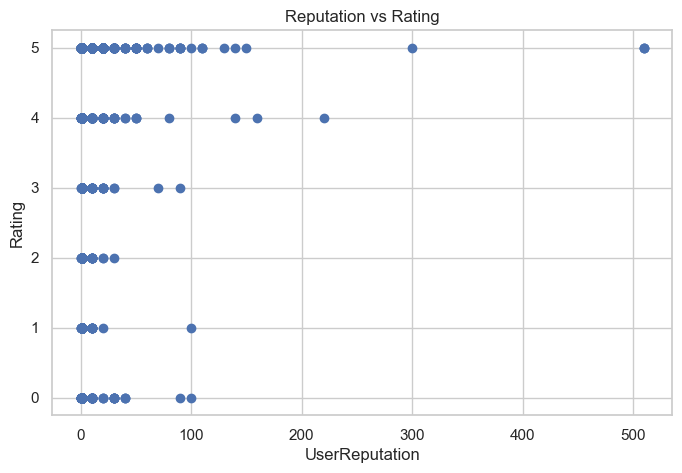

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(train['UserReputation'],train['Rating'])
plt.title("Reputation vs Rating")
plt.xlabel("UserReputation")
plt.ylabel("Rating")
plt.show()

- Most users have very low reputation (0–50 range)
- High reputation users are rare
- 5-star ratings dominate across all reputation levels
- No strong linear pattern between reputation and rating

In [13]:
train['UserReputation'].value_counts()

UserReputation
1      12708
10       478
20       217
0        118
30        54
50        16
40        12
90         7
80         4
60         4
110        3
510        3
100        3
140        2
70         2
220        1
160        1
130        1
150        1
300        1
Name: count, dtype: int64

The distribution of UserReputation is highly skewed. The majority of users have a reputation score of 1, indicating that most reviews are submitted by low-reputation users. Only a small number of users have high reputation values .

Due to this strong right-skewness and presence of extreme values, a log transformation will be applied during preprocessing to stabilize variance and reduce the impact of outliers.

### Time-Based Features: Convert CreationTimestamp (Unix) into human-readable features.

In [14]:
train['CreationTimestamp'] = pd.to_datetime(train['CreationTimestamp'], unit = 's') #numbers represent time in seconds, `unit='s'` to tell pandas that the numbers are in seconds and convert them correctly into date and time.
print(train['CreationTimestamp'].head())

train['hour'] = train['CreationTimestamp'].dt.hour
train['day_of_week'] = train['CreationTimestamp'].dt.dayofweek
train['month'] = train['CreationTimestamp'].dt.month

train = train.drop(columns=['CreationTimestamp'])
numeric_cols = ['RecipeNumber', 'UserReputation', 'ReplyCount', 'ThumbsUpCount', 'ThumbsDownCount', 'BestScore', 'hour', 'month']


0   2021-06-03 10:44:38
1   2021-06-03 10:57:32
2   2021-06-03 10:49:17
3   2021-06-02 15:48:19
4   2021-06-03 11:04:20
Name: CreationTimestamp, dtype: datetime64[ns]


used to just for analys,looking for any use with hour, day, month

# Correlation Heatmap

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 [Text(0.5, 0, 'RecipeNumber'),
  Text(1.5, 0, 'UserReputation'),
  Text(2.5, 0, 'ReplyCount'),
  Text(3.5, 0, 'ThumbsUpCount'),
  Text(4.5, 0, 'ThumbsDownCount'),
  Text(5.5, 0, 'BestScore'),
  Text(6.5, 0, 'hour'),
  Text(7.5, 0, 'month'),
  Text(8.5, 0, 'Rating')])

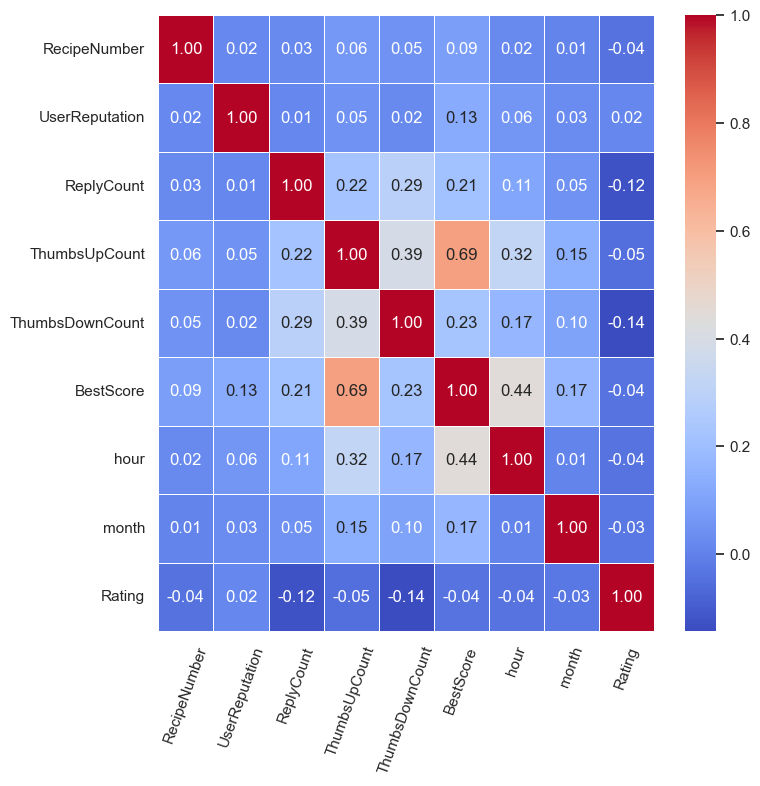

In [15]:
imp_columns = ['RecipeNumber', 'UserReputation', 'ReplyCount', 'ThumbsUpCount','ThumbsDownCount', 'BestScore', 'hour', 'month', 'Rating']
plt.figure(figsize = (8,8))
sns.heatmap(train[imp_columns].corr(), annot=True, cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.xticks(rotation=70)


There is relation between **best score** and **ThumbsUpCount**

also between hour and ThumbsUpCount

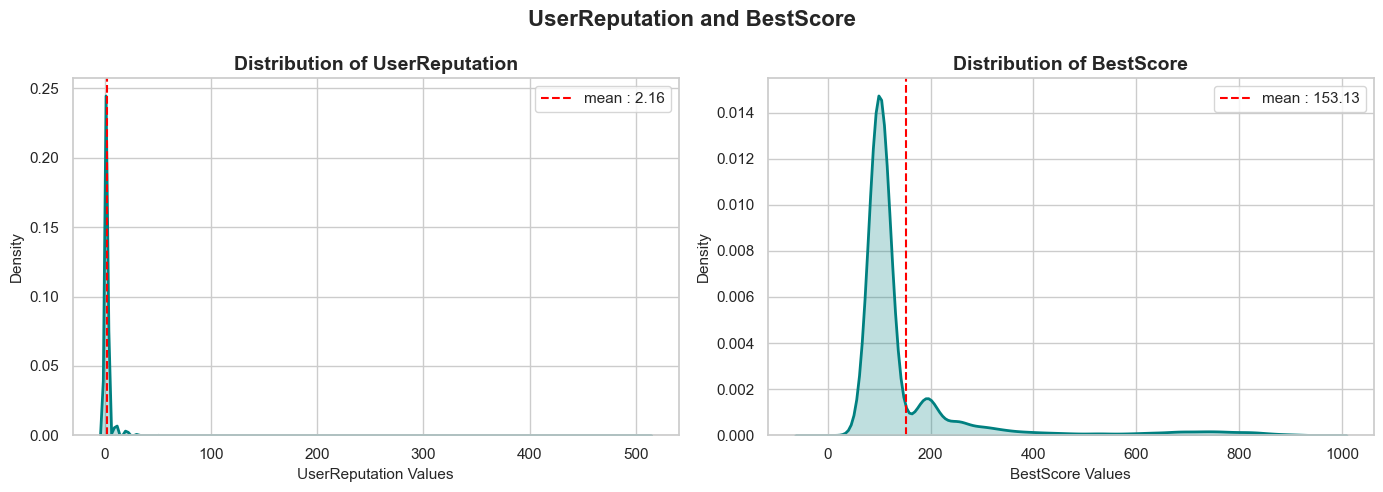

In [16]:
fig, ax = plt.subplots(1,2,figsize=(14, 5))

for i,col in  enumerate (['UserReputation','BestScore']):
    sns.kdeplot(data=train,x=col,fill = True,ax=ax[i],color = 'teal',linewidth=2)
    ax[i].set_title(f"Distribution of {col}",fontsize=14,fontweight='bold')
    ax[i].set_xlabel(f"{col} Values", fontsize=11)
    ax[i].set_ylabel("Density",fontsize=11)
    ax[i].axvline(train[col].mean(),color='red',linestyle='--',label=f'mean : {train[col].mean():.2f}')
    ax[i].legend()
plt.suptitle("UserReputation and BestScore", fontsize=16, fontweight='bold')
plt.tight_layout()


# Outlier Detection (Numerical Features)

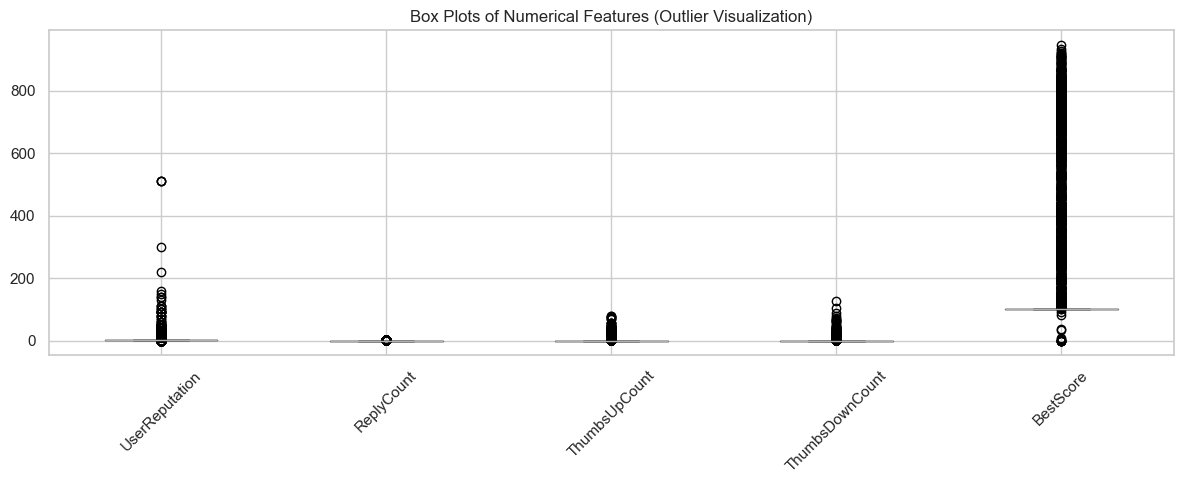

In [17]:
# Box plots for features that are not IDs (more interpretable)
plot_cols = ['UserReputation', 'ReplyCount', 'ThumbsUpCount', 'ThumbsDownCount', 'BestScore']
train[plot_cols].boxplot(figsize=(12, 5), rot=45)
plt.title("Box Plots of Numerical Features (Outlier Visualization)")
plt.tight_layout()
plt.show()

In [18]:
outlier_summary = {}

for col in plot_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train[(train[col] < lower_bound) | (train[col] > upper_bound)]
    
    outlier_summary[col] = {
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers.shape[0],
        "Outlier Percentage": round((outliers.shape[0] / len(train)) * 100, 2)
    }

pd.DataFrame(outlier_summary).T

,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
UserReputation,1.0,1.0,928.0,6.81
ReplyCount,0.0,0.0,172.0,1.26
ThumbsUpCount,0.0,0.0,3054.0,22.40
ThumbsDownCount,0.0,0.0,1820.0,13.35
BestScore,100.0,100.0,3130.0,22.95


Because features are highly right-skewed:

IQR will mark MANY values as outliers.These are NOT errors.They are natural heavy-tail distributions.

---
## 12. EDA Summary 



### Summary of findings

- **Dataset readiness**: Train has **13,636 rows** and includes both **numerical** and **categorical/text** features; test has **4,546 rows**.
- **Missing values**: `Recipe_Review` has a **very small number of nulls** (can be imputed as empty text).
- **Target distribution**: `Rating` is **imbalanced** (many 5-star ratings), so model evaluation should consider imbalance handling.
- **Outliers / skewness**: Engagement features (`ThumbsUpCount`, `ThumbsDownCount`, `ReplyCount`, `BestScore`) are **right-skewed**; many IQR “outliers” are **natural heavy-tail values**, not necessarily errors.
- **Pipeline implications**:
  - Use `ColumnTransformer` to apply **imputation + scaling** for numeric and **encoding** for categorical.
  - Treat ID-like columns (`ID`, `CommentID`, `UserID`) carefully to avoid leakage (often dropped from modeling features).

**Next step**: Implement preprocessing **inside an sklearn Pipeline** (no manual preprocessing outside), then build baseline + multiple models with cross-validation.

In [19]:
orginal_train_data.head()

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
0,70,71,12259,Banana Bars with Cream Cheese Frosting,sp_aUSaElGf_12259_c_149978,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,20,1622717078,0,0,0,5,100,great recipe! I have made them just as written...
1,72,88,8202,Simple Taco Soup,sp_aUSaElGf_8202_c_310332,u_1oKZeRIXYzGNhGW8OMR3O4lX1ih,MichelleMalone,1,1622717852,0,0,1,5,100,This is an easy and quick recipe that is great...
2,458,3,2832,Cheeseburger Soup,sp_aUSaElGf_2832_c_206522,u_1oKYHUtdaD48KJCDYq5wfpAUxWz,jeannem32,1,1622717357,0,0,0,3,100,I think I was looking for something extra spec...
3,7,50,100276,Grilled Huli Huli Chicken,sp_aUSaElGf_100276_c_434088,u_1oKZCQcKQZdQhDVBS7oISc216VA,ds422,1,1622648899,0,0,0,5,100,This is our favorite grilled chicken recipe. ...
4,60,12,19731,Cauliflower Soup,sp_aUSaElGf_19731_c_387011,u_1oKd4sudZQPgu6YALiC7bW7mKMs,SusanHoward,1,1622718260,0,0,0,4,100,Great basic recipe. I added 2 teaspoons Tuscan...


checking there is any change actual data

In [20]:
df_cleaned = orginal_train_data[orginal_train_data['Rating']!=0].copy() #0 means no meaning so we only taking from 1 to 5 rating

df_cleaned['Rating'].value_counts()

Rating
5    10371
4     1241
3      368
1      210
2      174
Name: count, dtype: int64

ensure that class are from 1 to 5. And choose 1 to 5 means we dont know 0 means , So avoid it. 

In [21]:
X = df_cleaned.drop('Rating',axis=1)
y = df_cleaned['Rating']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skewed_features = ["UserReputation", "ReplyCount", "ThumbsUpCount", "ThumbsDownCount", "BestScore"]
normal_features = ["RecipeNumber", "hour", "month"]
categorical_features = ["day_of_week"]


- split data into testing and training
- categoryed skewed feature and numeric because both are need differernt cleaning

In [22]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(9891, 14)
(2473, 14)
(9891,)
(2473,)


In [ ]:
import sys
import os

# This adds the 'src' directory to the python path
sys.path.append(os.path.abspath(r'D:\Bridgeon\Projects\recipe_rating_ML_project\src'))

from preprocessing import build_preprocessor
from model import baseline, evaluate_model  # creating base model

preprocessor = build_preprocessor(skewed_features, normal_features, categorical_features)
baseline_model = baseline(preprocessor)
evaluate_model(baseline_model, X_train, X_test, y_train, y_test)


Cross-validation(5) mean : 0.6245

Classification Report:
              precision    recall  f1-score   support

           1       0.19      0.55      0.28        42
           2       0.05      0.09      0.06        35
           3       0.02      0.03      0.02        74
           4       0.11      0.33      0.17       248
           5       0.87      0.61      0.72      2074

    accuracy                           0.56      2473
   macro avg       0.25      0.32      0.25      2473
weighted avg       0.75      0.56      0.63      2473

confusion_matrix 

[[  23    2    3    3   11]
 [  12    3    2    7   11]
 [  12    6    2   23   31]
 [  13    7   13   83  132]
 [  61   41   67  634 1271]]

 Multiclass ROC AUC Score (Weighted): 0.6055


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('date_features', DateFeatureExtractor()),
                                 ('column_transform',
                                  ColumnTransformer(transformers=[('skewed_num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('log_transform',
                                                                                    FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                   ('scaler',
                                                                                    StandardScaler())]),
                                                                   ['UserReputation',
                                                                    'ReplyCount',
                                                                    'ThumbsUpCount...
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('scaler',
                                                                                    StandardScaler())]),
                                                                   ['RecipeNumber',
                                                                    'hour',
                                                                    'month']),
                                                                  ('cat',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('encoder',
                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                   ['day_of_week'])]))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

- Average weighted F1 score across 5 training folds
- difference between Cross-validation(5) mean and weighted avg very low so **Model is stable**
- No overfitting (mean performed train and test are likely same)
- ROC AUC Score : 0.6055 **(0.6–0.7 → Poor)**
- in confusion_matrix  we can see its prediction are correct or not


In [24]:
from model import decision_tree
print("---Decision Tree---")
Decision_Tree = decision_tree(preprocessor)
evaluate_model(Decision_Tree,X_train, X_test, y_train, y_test)

---Decision Tree---
Cross-validation(5) mean : 0.7644

Classification Report:
              precision    recall  f1-score   support

           1       0.32      0.26      0.29        42
           2       0.12      0.09      0.10        35
           3       0.12      0.07      0.09        74
           4       0.10      0.03      0.05       248
           5       0.85      0.95      0.90      2074

    accuracy                           0.80      2473
   macro avg       0.31      0.28      0.28      2473
weighted avg       0.74      0.80      0.77      2473

confusion_matrix 

[[  11    4    1    2   24]
 [   4    3    3    1   24]
 [   3    5    5    4   57]
 [   3    0    7    8  230]
 [  13   13   24   63 1961]]

 Multiclass ROC AUC Score (Weighted): 0.5647


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('date_features', DateFeatureExtractor()),
                                 ('column_transform',
                                  ColumnTransformer(transformers=[('skewed_num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('log_transform',
                                                                                    FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                   ('scaler',
                                                                                    StandardScaler())]),
                                                                   ['UserReputation',
                                                                    'ReplyCount',
                                                                    'ThumbsUpCount...
                                                                    'BestScore']),
                                                                  ('normal_num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('scaler',
                                                                                    StandardScaler())]),
                                                                   ['RecipeNumber',
                                                                    'hour',
                                                                    'month']),
                                                                  ('cat',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('encoder',
                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                   ['day_of_week'])]))])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

- small difference between Cross-validation(5) mean and weighted avg **which means model is stable and No overfitting**
- **macro avg** is 0.28 so model performs badly on minority classes.
- ROC AUC is low or very poor or random separation

- it show weak class separation. macro avg is .28 and ROC AUC Score is .56


In [25]:
from model import gradient_boosting, random_forest

print("--- Training Random Forest with Tuning ---")
rf_grid = random_forest(preprocessor)
evaluate_model(rf_grid, X_train, X_test, y_train, y_test)

print("--- Training Gradient Boosting with Tuning ---")
gb_grid = gradient_boosting(preprocessor)
evaluate_model(gb_grid, X_train, X_test, y_train, y_test)

--- Training Random Forest with Tuning ---
Internal GridSearch CV F1: 0.7723
Best Params: {'classifier__max_depth': None, 'classifier__min_samples_split': 5}

Classification Report:
              precision    recall  f1-score   support

           1       0.28      0.17      0.21        42
           2       0.00      0.00      0.00        35
           3       0.22      0.03      0.05        74
           4       0.00      0.00      0.00       248
           5       0.85      0.99      0.91      2074

    accuracy                           0.83      2473
   macro avg       0.27      0.24      0.23      2473
weighted avg       0.72      0.83      0.77      2473

confusion_matrix 

[[   7    1    1    1   32]
 [   4    0    0    0   31]
 [   6    0    2    2   64]
 [   3    0    1    0  244]
 [   5    2    5   10 2052]]

 Multiclass ROC AUC Score (Weighted): 0.6018
--- Training Gradient Boosting with Tuning ---
Internal GridSearch CV F1: 0.7735
Best Params: {'classifier__learning_rate':

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        Pipeline(steps=[('date_features',
                                                         DateFeatureExtractor()),
                                                        ('column_transform',
                                                         ColumnTransformer(transformers=[('skewed_num',
                                                                                          Pipeline(steps=[('imputer',
                                                                                                           SimpleImputer(strategy='median')),
                                                                                                          ('log_transform',
                                                                                                           FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                                          ('scaler',
                                                                                                           StandardScaler())]),
                                                                                          ['UserReputation'...
                                                                                           'hour',
                                                                                           'month']),
                                                                                         ('cat',
                                                                                          Pipeline(steps=[('imputer',
                                                                                                           SimpleImputer(strategy='most_frequent')),
                                                                                                          ('encoder',
                                                                                                           OneHotEncoder(handle_unknown='ignore'))]),
                                                                                          ['day_of_week'])]))])),
                                       ('classifier',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.05, 0.1],
                         'classifier__n_estimators': [100, 200]},
             scoring='f1_weighted')

- in **Random Forest(Reduces variance)** it tuned best params as classifier__max_depth': None, 'classifier__min_samples_split': 5
- compare to DT, Basline its slightly better in CV Mean
- model is collapsing many classes into class 5.
- accuracy alone doesn't stand chance in imbalanced dataset

- **Gradient Boosting Result**
- Slight improvement in weighted F1 (0.78)
- almost same as above

Random Forest and Gradient Boosting models have 0.00 recall for ratings 2, 3, and 4. This means the model is ignoring this class to achieve high accuracy on the 5-star majority

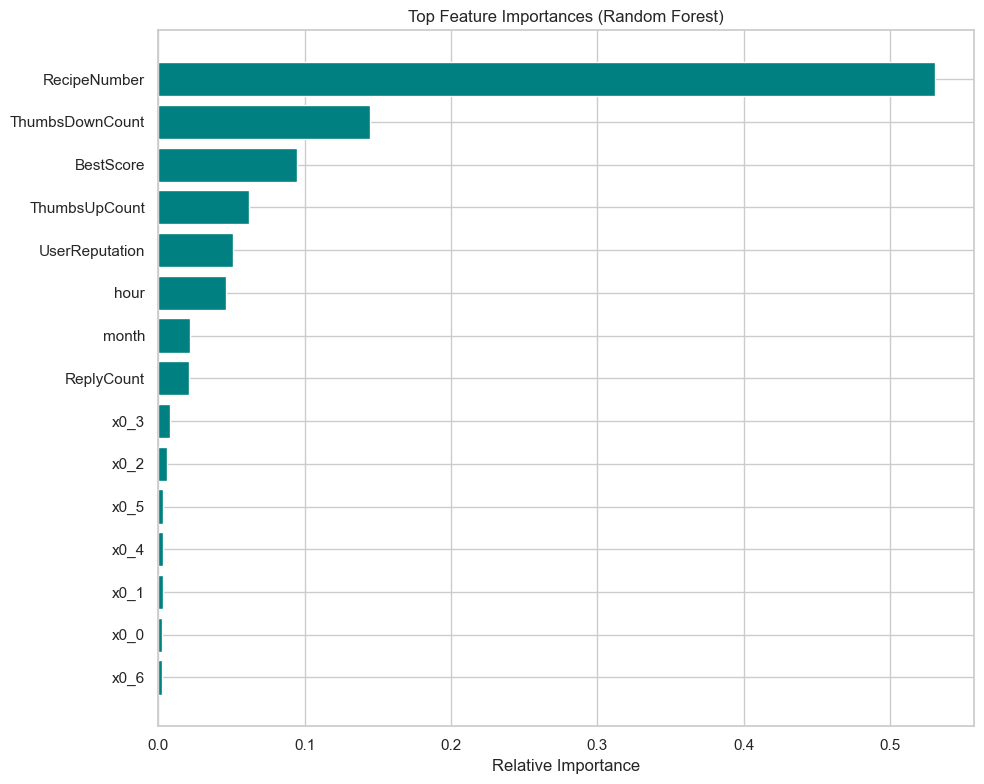

In [26]:
best_pipeline = rf_grid.best_estimator_#give as full trained model with best parameters
best_rf_model = best_pipeline.named_steps['classifier']
importances = best_rf_model.feature_importances_

preprocessor_obj = best_pipeline.named_steps['preprocessor'].named_steps['column_transform']

# Combine all feature names in the correct order
feature_names = (skewed_features + normal_features + list(preprocessor_obj.transformers_[2][1].named_steps['encoder'].get_feature_names_out()))

# 5. Plotting
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('Top Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

- Feature Importance  (Random Forest)
- top contributing features are 
- **RecipeNumber** has maybe ranking information
- **ThumbsDownCount** negative feedback
- **BestScore** High BestScore likely increases probability of high class predictions.
- **ThumbsUpCount** it also helps to predicit high classes
- **UserReputation** Users with  high reputation tend to give more stable and reliable ratings

## importance aligns with EDA findings.
- as observed **high skewness** in rating distribution (Class 5 dominant).


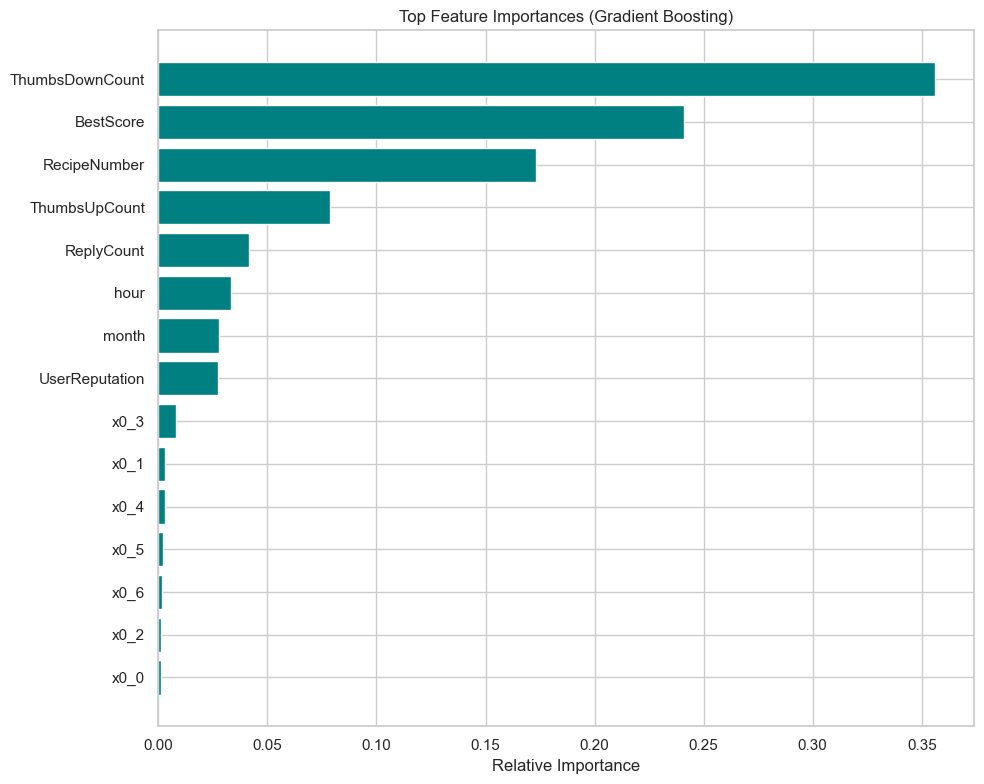

In [29]:
best_pipeline = gb_grid.best_estimator_
best_gb_model = best_pipeline.named_steps['classifier']
importances = best_gb_model.feature_importances_

preprocessor_obj = best_pipeline.named_steps['preprocessor'].named_steps['column_transform']

# Combine all feature names in the correct order
feature_names = (skewed_features + 
                 normal_features + 
                 list(preprocessor_obj.transformers_[2][1].named_steps['encoder'].get_feature_names_out()))

# 5. Plotting
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('Top Feature Importances (Gradient Boosting)')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

- Feature Importance (Gradient Boosting)

- Top contributing features are:
- **ThumbsDownCount** More dislikes push predictions toward lower ratings.
- **BestScore** High BestScore increases probability of high class predictions.
- **RecipeNumber** May contain ranking or structural information.
- **ThumbsUpCount**  Helps predict higher ratings.
- **ReplyCount**  More discussion/engagement may influence rating prediction.

## Importance aligns with EDA findings.
- Ratings are highly imbalanced (Class 5 dominant).
- Engagement features (likes/dislikes) strongly influence predictions.

| Model                  | CV F1-Score | Test Accuracy | Weighted F1 | ROC-AUC |
|------------------------|------------:|--------------:|------------:|--------:|
| Baseline (Logistic)    | 0.6245      | 0.56          | 0.63        | 0.6055  |
| Decision Tree          | 0.7644      | 0.80          | 0.77        | 0.5647  |
| Random Forest          | 0.7723      | 0.83          | 0.77        | 0.6018  |
| Gradient Boosting      | 0.7735      | 0.84          | 0.78        | 0.6176  |

based on top standing model is Gradient Boosting

In [30]:
test_df = pd.read_csv(r"D:\Bridgeon\Projects\recipe_rating_ML_project\data\test.csv")

final_prediction = gb_grid.best_estimator_.predict(test_df)

submission_results = pd.DataFrame({
    "RecipeName": test_df["RecipeName"],
    "Predicted_Rating" : final_prediction   
})

print(submission_results)

                                    RecipeName  Predicted_Rating
0                 Black Bean ‘n’ Pumpkin Chili                 5
1                                 Pumpkin Bars                 5
2                                 Pumpkin Bars                 5
3                          Porcupine Meatballs                 5
4                      Easy Chicken Enchiladas                 5
...                                        ...               ...
4541                           Seafood Lasagna                 5
4542                    Pineapple Pudding Cake                 5
4543  Contest-Winning New England Clam Chowder                 5
4544                          Cauliflower Soup                 5
4545                   Teriyaki Chicken Thighs                 5

[4546 rows x 2 columns]


In [31]:
submission_results['Predicted_Rating'].value_counts()

Predicted_Rating
5    4492
1      26
3      16
4       9
2       3
Name: count, dtype: int64

The main reason is give 5 star is class imbalance 

In [ ]:
import joblib

joblib.dump(gb_grid.best_estimator_, 'recipe_rating_pipline.pkl')

#How to use 
# loaded_model = joblib.load('recipe_rating_pipline.pkl')
# data = new_data
# prediction = loaded_model.predict(data)

['recipe_rating_pipline.pkl']